In [44]:
import numpy as np
import os
import random
import numpy as np
from scipy.special import lambertw
import numpy as np
import matplotlib.pyplot as plt
def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)  # For hash-based operations
    random.seed(seed)                         # Python RNG
    np.random.seed(seed)    
def sigmoid(x):
    return 1/(1 + np.exp(-x))
def logit(p,eps=1e-9):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))
def softmax(x):
    x = np.array(x)
    # subtract max for numerical stability
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=-1, keepdims=True)
def chi2max(x):
    x = np.array(x)
    e_x = lambertw(np.exp(x))
    return e_x / e_x.sum(axis=-1, keepdims=True)
def posmax(x):
    e_x = x
    e_x[x<0] = 0
    assert(np.all(e_x == x))
    return e_x / e_x.sum(axis=-1, keepdims=True)

def PEPO(first_actions, second_actions, preferences, L,std_coeff, mode="std",chi_squared=False,beta=0.05):
    if L > 1 and std_coeff > 0:
        reward = np.zeros((L,n_actions))
        n = len(preferences)
        partition = [preferences[i*n//L : (i+1)*n//L] for i in range(L)]
        first_actions_partition = [first_actions[i*n//L : (i+1)*n//L] for i in range(L)]
        second_actions_partition = [second_actions[i*n//L : (i+1)*n//L] for i in range(L)]
        for l,preferences_batch, first_actions_batch,second_actions_batch \
        in zip(range(L),partition,first_actions_partition, second_actions_partition ):
            deltas = np.zeros((n_actions,n_actions))
            deltas[first_actions_batch,second_actions_batch] += preferences_batch
            counts = np.ones((n_actions,n_actions))
            counts[first_actions_batch,second_actions_batch] += 1
            deltas /= counts
            first_missing = [i for i in range(n_actions) if i not in set(first_actions_batch)]
            second_missing = [i for i in range(n_actions) if i not in set(second_actions_batch)]
            deltas[first_missing,:] = 0.5
            deltas[:,second_missing] = 0.5
            reward[l] = np.mean(deltas,axis=1)
        if mode == "std":
            vals = np.mean(reward, axis=0) - std_coeff*np.std(reward, axis=0) 
        elif mode == "min":
            vals = np.min(reward, axis=0)
        else: print("Mode not available")
        candidates = np.where(vals == vals.max())[0]      # all max positions
        chosen_action = np.random.choice(candidates)  
        return means[chosen_action]
    else:
        reward = np.zeros((n_actions))
        deltas = np.zeros((n_actions,n_actions))
        deltas[first_actions,second_actions] += preferences
        counts = np.ones((n_actions,n_actions))
        counts[first_actions,second_actions] += 1
        deltas /= counts
        first_missing = [i for i in range(n_actions) if i not in set(first_actions)]
        second_missing = [i for i in range(n_actions) if i not in set(second_actions)]
        deltas[first_missing,:] = 0.5
        deltas[:,second_missing] = 0.5
        reward = np.mean(deltas,axis=1)
        if not chi_squared:
            probs = softmax(reward/beta)
        else:
            probs = posmax((reward - beta*np.mean(reward)))
        #candidates = np.where(reward == reward.max())[0]      # all max positions
        #chosen_action = np.random.choice(candidates)  
        
    return means@probs

In [32]:
#Experiment 1
n_actions = 10
means = np.ones(n_actions)
means[0] = 2
variances = np.ones(n_actions)
variances[0] = 0.01
N=1000
maxL=10
seeds=10
std_coeffs = [0, 0.5, 2]
perf=np.zeros((len(std_coeffs),seeds,maxL))
for seed in range(seeds):
    set_seed(seed)
    first_actions = np.random.choice(n_actions, N)
    second_actions = np.random.choice(n_actions, N)
    prob_first_win =[]
    for a1,a2 in zip(first_actions,second_actions ):
        reward1 = np.random.normal(loc=means[a1], scale=np.sqrt(variances[a1]))
        reward2 = np.random.normal(loc=means[a2], scale=np.sqrt(variances[a2]))
        prob_first_win.append(sigmoid(reward1 - reward2))
    preferences = (np.random.rand(N) < prob_first_win).astype(int)
    for L in np.arange(1,maxL+1):
        for j, std_coeff in enumerate(std_coeffs):
            perf[j,seed,L-1] = PEPO(first_actions, second_actions, preferences, L, std_coeff)

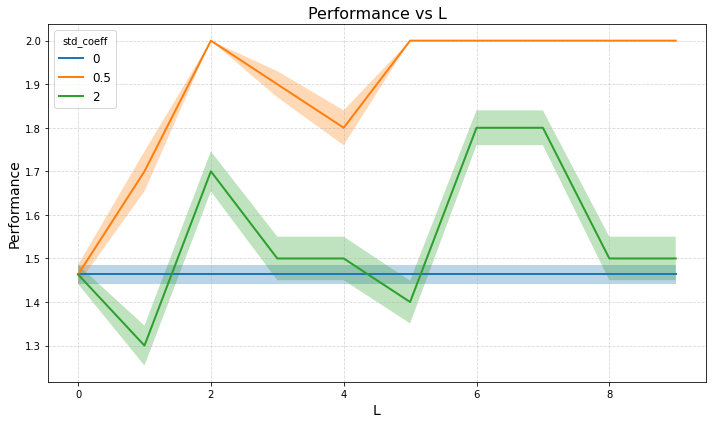

In [33]:

# Create the plot
plt.figure(figsize=(10, 6))
for j,p in enumerate(perf):
    # Compute statistics once for clarity
    mean_perf = np.mean(p, axis=0)
    std_perf = np.std(p, axis=0)
    if j == 0:
        mean_perf = np.mean(mean_perf)*np.ones(maxL)
        std_perf = np.mean(std_perf)*np.ones(maxL)
    lower = mean_perf - 0.1 * std_perf
    upper = mean_perf + 0.1 * std_perf
    
    plt.plot(mean_perf, linewidth=2, label=f"{std_coeffs[j]}")
    plt.fill_between(range(len(mean_perf)), lower, upper, alpha=0.3)
plt.title('Performance vs L', fontsize=16)
plt.xlabel('L', fontsize=14)
plt.ylabel('Performance', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12, title="std_coeff")
plt.tight_layout()
plt.savefig("figures/RLHFvsL.pdf")
plt.show()

In [34]:
#Loop over the samples

In [61]:
#Experiment 2
n_actions = 20
means = np.ones(n_actions)
means[0] = 2.9 # 2.5 #2
variances = np.ones(n_actions)
variances[0] = 0.5 #0.01
Ns =  [30,50,100,200,300,500,1000,2000,5000,10000] #[100, 500, 1000, 5000, 10000]
maxL=10
seeds=5
std_coeff= 0.5
perf=np.zeros((maxL,seeds, len(Ns)))
chi2perf=np.zeros((seeds, len(Ns)))
for seed in range(seeds):
    set_seed(seed)
    for j, N in enumerate(Ns):
        first_actions = np.random.choice(n_actions, N)
        second_actions = np.random.choice(n_actions, N)
        prob_first_win =[]
        for a1,a2 in zip(first_actions,second_actions ):
            reward1 = np.random.normal(loc=means[a1], scale=np.sqrt(variances[a1]))
            reward2 = np.random.normal(loc=means[a2], scale=np.sqrt(variances[a2]))
            prob_first_win.append(sigmoid(reward1 - reward2))
        preferences = (np.random.rand(N) < prob_first_win).astype(int)
        chi2perf[seed,j] = PEPO(first_actions, second_actions, preferences, 1, std_coeff,chi_squared=True, beta=1.25)
        for L in np.arange(1,maxL+1):
            perf[L-1,seed,j] = PEPO(first_actions, second_actions, preferences, L, std_coeff)
            


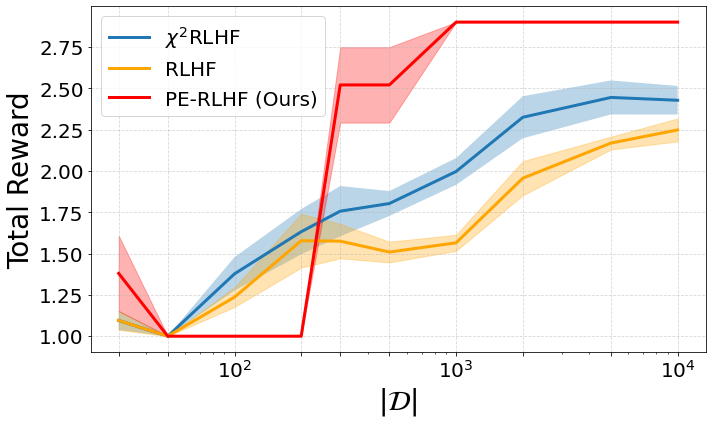

In [62]:

plt.figure(figsize=(10, 6))
mean_perf = np.mean(chi2perf, axis=0)
std_perf = np.std(chi2perf, axis=0)
lower = mean_perf - 0.3*std_perf
upper = mean_perf + 0.3*std_perf
plt.semilogx(Ns, mean_perf, linewidth=3, label=rf"$\chi^2$RLHF")
plt.fill_between(Ns, lower, upper, alpha=0.3)
for j,p in enumerate(perf):
    if not j % 2 and not j==8 and not j==4 and not j==6:
    # Compute statistics once for clarity
        mean_perf = np.mean(p, axis=0)
        std_perf = np.std(p, axis=0)
        lower = mean_perf - 0.3*std_perf
        upper = mean_perf + 0.3*std_perf
        plt.semilogx(Ns, mean_perf, linewidth=3, label=rf"PE-RLHF (Ours)" if not j==0 else r"RLHF",
                    color = "red" if not j==0 else "orange" )
        plt.fill_between(Ns, lower, upper, alpha=0.3, color = "red" if not j==0 else "orange")

plt.xlabel(r'$\| \mathcal{D} \|$', fontsize=28)
plt.xticks(Ns,fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel(r'Total Reward', fontsize=28)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig("figures/RLHFvsN.pdf")
plt.show()


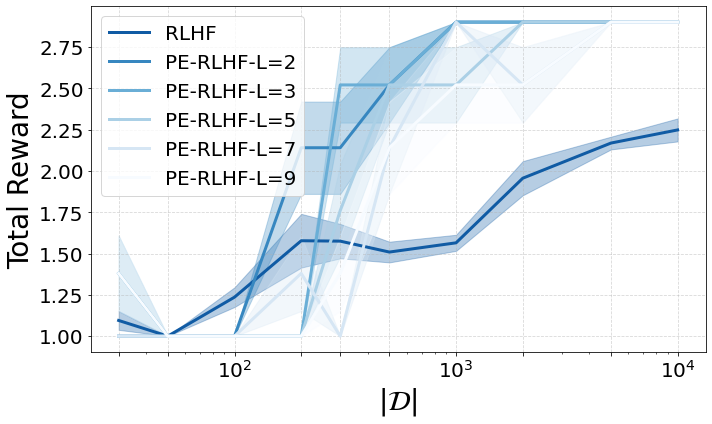

In [63]:
plt.figure(figsize=(10, 6))

# Use the "Blues" colormap
cmap = plt.cm.Blues

# Identify which indices you're plotting (even j > 0)
indices = [0] + [1] + [j for j in range(len(perf)) if j > 0 and j % 2 == 0]
num_colors = len(indices)

for idx, j in enumerate(indices):
    p = perf[j]
    mean_perf = np.mean(p, axis=0)
    std_perf = np.std(p, axis=0)
    lower = mean_perf - 0.3 * std_perf
    upper = mean_perf + 0.3 * std_perf

    # Reverse color order: darker for smaller j
    color = cmap(1 - (idx + 1) / num_colors)

    plt.semilogx(
        Ns,
        mean_perf,
        linewidth=3,
        color=color,
        label=rf"PE-RLHF-L={j+1}" if j != 0 else r"RLHF"
    )
    plt.fill_between(Ns, lower, upper, alpha=0.3, color=color)

plt.xlabel(r'$\| \mathcal{D} \|$', fontsize=28)
plt.xticks(Ns, fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel(r'Total Reward', fontsize=28)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig("figures/PERLHFabl.pdf")
plt.show()

# Experiments with min mode

In [7]:
n_actions = 20 #5
means = np.ones(n_actions)
means[0] = 2.9
variances = np.ones(n_actions)
variances[0] = 0.5 #0.005
Ns = [30,50,100,200,300,500,1000,2000,5000,10000,50000] #[100, 500, 1000, 5000, 10000]
maxL=10
seeds=5
perf=np.zeros((maxL,seeds, len(Ns)))
for seed in range(seeds):
    set_seed(seed)
    for j, N in enumerate(Ns):
        first_actions = np.random.choice(n_actions, N)
        second_actions = np.random.choice(n_actions, N)
        prob_first_win =[]
        for a1,a2 in zip(first_actions,second_actions ):
            reward1 = np.random.normal(loc=means[a1], scale=np.sqrt(variances[a1]))
            reward2 = np.random.normal(loc=means[a2], scale=np.sqrt(variances[a2]))
            prob_first_win.append(sigmoid(reward1 - reward2))
        preferences = (np.random.rand(N) < prob_first_win).astype(int)
        for L in np.arange(1,maxL+1):
            perf[L-1,seed,j] = PEPO(first_actions, second_actions, preferences, L, std_coeff, mode="min")
            
chi2perf=np.zeros((seeds, len(Ns)))
for seed in range(seeds):
    set_seed(seed)
    for j, N in enumerate(Ns):
        first_actions = np.random.choice(n_actions, N)
        second_actions = np.random.choice(n_actions, N)
        prob_first_win =[]
        for a1,a2 in zip(first_actions,second_actions ):
            reward1 = np.random.normal(loc=means[a1], scale=np.sqrt(variances[a1]))
            reward2 = np.random.normal(loc=means[a2], scale=np.sqrt(variances[a2]))
            prob_first_win.append(sigmoid(reward1 - reward2))
        preferences = (np.random.rand(N) < prob_first_win).astype(int)
        
        chi2perf[seed,j] = PEPO(first_actions, second_actions, preferences, 1, std_coeff, mode="min", beta=0.005,chi_squared=True)

/var/folders/84/_gh7j8tj4dj9p4vytdb2m5h00000gn/T/ipykernel_79642/4002482360.py:37: ComplexWarning: Casting complex values to real discards the imaginary part
  chi2perf[seed,j] = PEPO(first_actions, second_actions, preferences, 1, std_coeff, mode="min", beta=0.005,chi_squared=True)


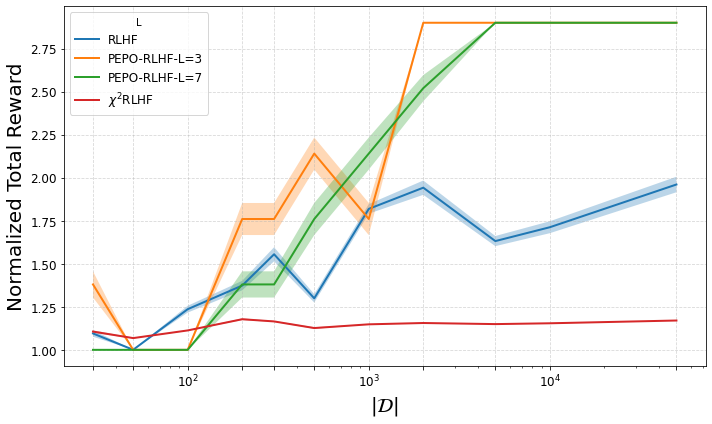

In [8]:
# Create the plot
plt.figure(figsize=(10, 6))
for j,p in enumerate(perf):
    if not j % 2 and not j==8 and not j==4:
    # Compute statistics once for clarity
        mean_perf = np.mean(p, axis=0)
        std_perf = np.std(p, axis=0)
        lower = mean_perf - 0.1 * std_perf
        upper = mean_perf + 0.1 * std_perf
        plt.semilogx(Ns, mean_perf, linewidth=2, label=rf"PE-RLHF-L={j+1}" if not j==0 else r"RLHF")
        plt.fill_between(Ns, lower, upper, alpha=0.3)
mean_perf = np.mean(chi2perf, axis=0)
std_perf = np.std(chi2perf, axis=0)
lower = mean_perf - 0.1 * std_perf
upper = mean_perf + 0.1 * std_perf
plt.semilogx(Ns, mean_perf, linewidth=2, label=rf"$\chi^2$RLHF")
plt.fill_between(Ns, lower, upper, alpha=0.3)
plt.xlabel(r'$\| \mathcal{D} \|$', fontsize=20)
plt.xticks(Ns,fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel(r'Normalized Total Reward', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12, title=r"L")
plt.tight_layout()
plt.savefig("figures/RLHFminvsN.pdf")
plt.show()

# DPO experiments

In [57]:
def PEPO_DPO(first_actions, second_actions, preferences, L,std_coeff, beta = 0.1,mode="std",chi_squared=False):
    if L > 1 and std_coeff > 0:
        policies = np.zeros((L,n_actions))
        n = len(preferences)
        partition = [preferences[i*n//L : (i+1)*n//L] for i in range(L)]
        first_actions_partition = [first_actions[i*n//L : (i+1)*n//L] for i in range(L)]
        second_actions_partition = [second_actions[i*n//L : (i+1)*n//L] for i in range(L)]
        for l,preferences_batch, first_actions_batch,second_actions_batch \
        in zip(range(L),partition,first_actions_partition, second_actions_partition ):
            deltas = np.zeros((n_actions,n_actions))
            deltas[first_actions_batch,second_actions_batch] += preferences_batch
            counts = np.ones((n_actions,n_actions))
            counts[first_actions_batch,second_actions_batch] += 1
            deltas /= counts
            first_missing = [i for i in range(n_actions) if i not in set(first_actions_batch)]
            second_missing = [i for i in range(n_actions) if i not in set(second_actions_batch)]
            deltas[first_missing,:] = 0.5
            deltas[:,second_missing] = 0.5
            policies[l] = softmax(np.mean(logit(deltas),axis=1)/beta)
        if mode == "std":
            # compute mean - std_coeff * std
            a = np.mean(policies, axis=0) - std_coeff * np.std(policies, axis=0)
            policy = np.maximum(a, 0)
        elif mode == "min":
            policy = np.min(policies, axis=0)
        else: print("Mode not available")
        policy/=np.sum(policy)
        return means.dot(policy)
    else:
        reward = np.zeros((n_actions))
        deltas = np.zeros((n_actions,n_actions))
        deltas[first_actions,second_actions] += preferences
        counts = np.ones((n_actions,n_actions))
        counts[first_actions,second_actions] += 1
        deltas /= counts
        first_missing = [i for i in range(n_actions) if i not in set(first_actions)]
        second_missing = [i for i in range(n_actions) if i not in set(second_actions)]
        deltas[first_missing,:] = 0.5
        deltas[:,second_missing] = 0.5
        if not chi_squared:
            policy = softmax(np.mean(logit(deltas),axis=1)/beta)
        else:
            policy = chi2max(np.mean(logit(deltas),axis=1)/beta)
        return means.dot(policy)

In [10]:
#Experiment 1 std
n_actions = 20
means = np.ones(n_actions)
means[0] = 2.9
variances = np.ones(n_actions)
variances[0] = 0.5
Ns = [30,50,100,200,300,500,1000,2000,5000,10000,50000] #[100, 500, 1000, 5000, 10000]
maxL=10
seeds=5
std_coeff= 0.5
perf=np.zeros((maxL,seeds, len(Ns)))
for seed in range(seeds):
    set_seed(seed)
    for j, N in enumerate(Ns):
        first_actions = np.random.choice(n_actions, N)
        second_actions = np.random.choice(n_actions, N)
        prob_first_win =[]
        for a1,a2 in zip(first_actions,second_actions ):
            reward1 = np.random.normal(loc=means[a1], scale=np.sqrt(variances[a1]))
            reward2 = np.random.normal(loc=means[a2], scale=np.sqrt(variances[a2]))
            prob_first_win.append(sigmoid(reward1 - reward2))
        preferences = (np.random.rand(N) < prob_first_win).astype(int)
        for L in np.arange(1,maxL+1):
            perf[L-1,seed,j] = PEPO_DPO(first_actions, second_actions, preferences, L, std_coeff)
            
chi2perf=np.zeros((seeds, len(Ns)))
for seed in range(seeds):
    set_seed(seed)
    for j, N in enumerate(Ns):
        first_actions = np.random.choice(n_actions, N)
        second_actions = np.random.choice(n_actions, N)
        prob_first_win =[]
        for a1,a2 in zip(first_actions,second_actions ):
            reward1 = np.random.normal(loc=means[a1], scale=np.sqrt(variances[a1]))
            reward2 = np.random.normal(loc=means[a2], scale=np.sqrt(variances[a2]))
            prob_first_win.append(sigmoid(reward1 - reward2))
        preferences = (np.random.rand(N) < prob_first_win).astype(int)
        
        chi2perf[seed,j] = PEPO_DPO(first_actions, second_actions, preferences, 1, std_coeff, mode="min", beta=0.5,chi_squared=True)

/var/folders/84/_gh7j8tj4dj9p4vytdb2m5h00000gn/T/ipykernel_79642/2128587355.py:39: ComplexWarning: Casting complex values to real discards the imaginary part
  chi2perf[seed,j] = PEPO_DPO(first_actions, second_actions, preferences, 1, std_coeff, mode="min", beta=0.5,chi_squared=True)


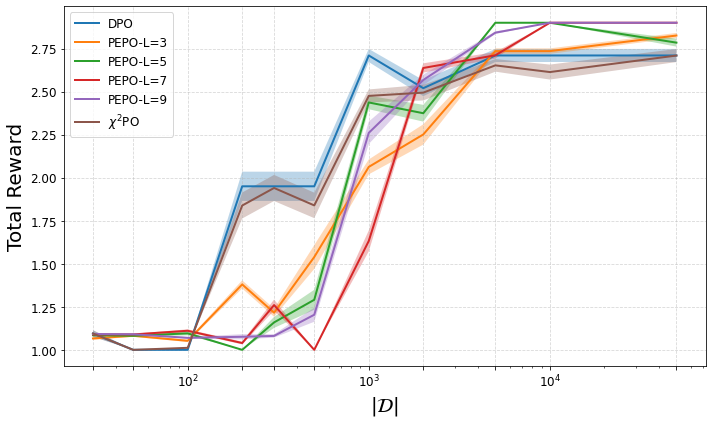

In [11]:
# Create the plot
plt.figure(figsize=(10, 6))
for j,p in enumerate(perf):
    if not j % 2:
        # Compute statistics once for clarity
        mean_perf = np.mean(p, axis=0)
        std_perf = np.std(p, axis=0)
        lower = mean_perf - 0.1 * std_perf
        upper = mean_perf + 0.1 * std_perf
        plt.semilogx(Ns, mean_perf, linewidth=2, label=rf"PEPO-L={j+1}" if not j==0 else r"DPO")
        plt.fill_between(Ns, lower, upper, alpha=0.3)
mean_perf = np.mean(chi2perf, axis=0)
std_perf = np.std(chi2perf, axis=0)
lower = mean_perf - 0.1 * std_perf
upper = mean_perf + 0.1 * std_perf
plt.semilogx(Ns, mean_perf, linewidth=2, label=rf"$\chi^2$PO")
plt.fill_between(Ns, lower, upper, alpha=0.3)
plt.xlabel(r'$\| \mathcal{D} \|$', fontsize=20)
plt.xticks(Ns,fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel(r'Total Reward', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures/DPOvsN.pdf")
plt.show()

In [12]:
# Experiment 2 DPO_MIN

In [58]:
n_actions = 20
means = np.ones(n_actions)
means[0] = 2.9
variances = np.ones(n_actions)
variances[0] = 0.5
Ns = [30,50,100,200,300,500,1000,2000,5000,10000,50000]#[100, 500, 1000, 5000, 10000]
maxL=10
seeds=5
perf=np.zeros((maxL,seeds, len(Ns)))
for seed in range(seeds):
    set_seed(seed)
    for j, N in enumerate(Ns):
        first_actions = np.random.choice(n_actions, N)
        second_actions = np.random.choice(n_actions, N)
        prob_first_win =[]
        for a1,a2 in zip(first_actions,second_actions ):
            reward1 = np.random.normal(loc=means[a1], scale=np.sqrt(variances[a1]))
            reward2 = np.random.normal(loc=means[a2], scale=np.sqrt(variances[a2]))
            prob_first_win.append(sigmoid(reward1 - reward2))
        preferences = (np.random.rand(N) < prob_first_win).astype(int)
        for L in np.arange(1,maxL+1):
            perf[L-1,seed,j] = PEPO_DPO(first_actions, second_actions, preferences, L, std_coeff, mode="min", beta=0.05)

chi2perf=np.zeros((seeds, len(Ns)))
for seed in range(seeds):
    set_seed(seed)
    for j, N in enumerate(Ns):
        first_actions = np.random.choice(n_actions, N)
        second_actions = np.random.choice(n_actions, N)
        prob_first_win =[]
        for a1,a2 in zip(first_actions,second_actions ):
            reward1 = np.random.normal(loc=means[a1], scale=np.sqrt(variances[a1]))
            reward2 = np.random.normal(loc=means[a2], scale=np.sqrt(variances[a2]))
            prob_first_win.append(sigmoid(reward1 - reward2))
        preferences = (np.random.rand(N) < prob_first_win).astype(int)
        
        chi2perf[seed,j] = PEPO_DPO(first_actions, second_actions, preferences, 1, std_coeff, mode="min", beta=0.5,chi_squared=True)


/var/folders/84/_gh7j8tj4dj9p4vytdb2m5h00000gn/T/ipykernel_3337/1742168895.py:37: ComplexWarning: Casting complex values to real discards the imaginary part
  chi2perf[seed,j] = PEPO_DPO(first_actions, second_actions, preferences, 1, std_coeff, mode="min", beta=0.5,chi_squared=True)


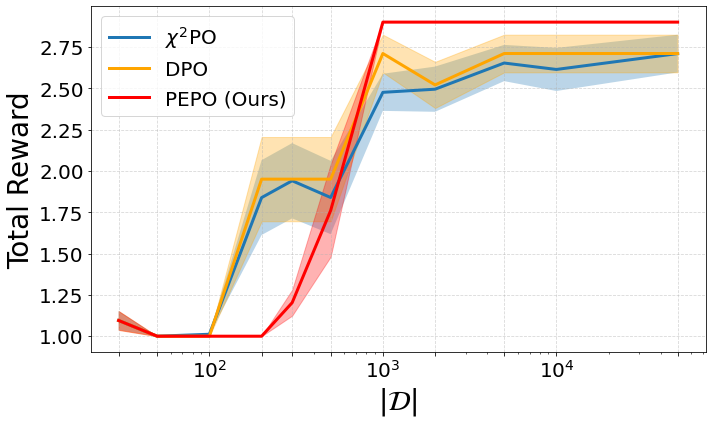

In [59]:
# Create the plot
plt.figure(figsize=(10, 6))
mean_perf = np.mean(chi2perf, axis=0)
std_perf = np.std(chi2perf, axis=0)
lower = mean_perf - 0.3*std_perf
upper = mean_perf + 0.3*std_perf
plt.semilogx(Ns, mean_perf, linewidth=3, label=rf"$\chi^2$PO")
plt.fill_between(Ns, lower, upper, alpha=0.3)
for j,p in enumerate(perf):
    if not j % 2 and not j==8 and not j==4 and not j==6:
    # Compute statistics once for clarity
        mean_perf = np.mean(p, axis=0)
        std_perf = np.std(p, axis=0)
        lower = mean_perf - 0.3*std_perf
        upper = mean_perf + 0.3*std_perf
        plt.semilogx(Ns, mean_perf, linewidth=3, label=rf"PEPO (Ours)" if not j==0 else r"DPO",
                    color = "red" if not j==0 else "orange" )
        plt.fill_between(Ns, lower, upper, alpha=0.3, color = "red" if not j==0 else "orange")

plt.xlabel(r'$\| \mathcal{D} \|$', fontsize=28)
plt.xticks(Ns,fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel(r'Total Reward', fontsize=28)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig("figures/DPOminvsN.pdf")
plt.show()

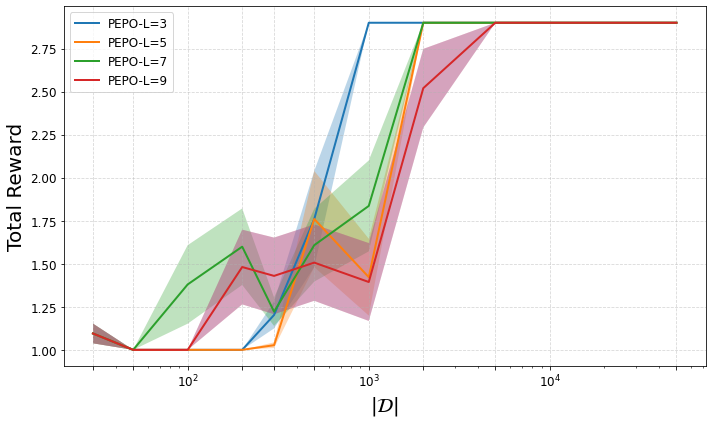

In [20]:
# PEPO ablation
plt.figure(figsize=(10, 6))
for j,p in enumerate(perf):
    if not j % 2 and j> 0: # and not j==8 and not j==4:
    # Compute statistics once for clarity
        mean_perf = np.mean(p, axis=0)
        std_perf = np.std(p, axis=0)
        lower = mean_perf - 0.3*std_perf
        upper = mean_perf + 0.3*std_perf
        plt.semilogx(Ns, mean_perf, linewidth=2, label=rf"PEPO-L={j+1}" if not j==0 else r"DPO")
        plt.fill_between(Ns, lower, upper, alpha=0.3)

plt.fill_between(Ns, lower, upper, alpha=0.3)
plt.xlabel(r'$\| \mathcal{D} \|$', fontsize=20)
plt.xticks(Ns,fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel(r'Total Reward', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures/PEPOabl.pdf")
plt.show()

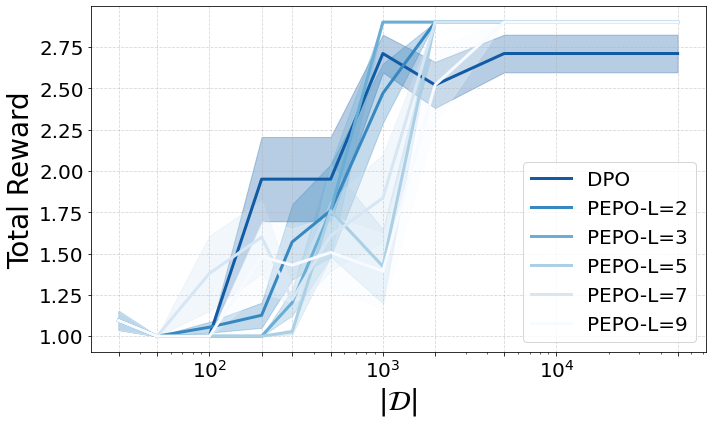

In [60]:
plt.figure(figsize=(10, 6))

# Use the "Blues" colormap
cmap = plt.cm.Blues

# Identify which indices you're plotting (even j > 0)
indices = [0] + [1] + [j for j in range(len(perf)) if j > 0 and j % 2 == 0]
num_colors = len(indices)

for idx, j in enumerate(indices):
    p = perf[j]
    mean_perf = np.mean(p, axis=0)
    std_perf = np.std(p, axis=0)
    lower = mean_perf - 0.3 * std_perf
    upper = mean_perf + 0.3 * std_perf

    # Reverse color order: darker for smaller j
    color = cmap(1 - (idx + 1) / num_colors)

    plt.semilogx(
        Ns,
        mean_perf,
        linewidth=3,
        color=color,
        label=rf"PEPO-L={j+1}" if j != 0 else r"DPO"
    )
    plt.fill_between(Ns, lower, upper, alpha=0.3, color=color)

plt.xlabel(r'$\| \mathcal{D} \|$', fontsize=28)
plt.xticks(Ns, fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel(r'Total Reward', fontsize=28)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig("figures/PEPOabl.pdf")
plt.show()